# Multi-Stage Training: Guarino -> Soft-DTW

Two-stage curriculum approach:
1. **Stage 1 (Guarino loss)**: Coarse feature matching — spike count, firing rate, first/last spike times
2. **Stage 2 (Soft-DTW loss)**: Fine-tune temporal alignment using differentiable time warping

The hypothesis is that Guarino loss gets parameters into the right ballpark (correct spike count),
then Soft-DTW refines spike timing to improve the coincidence factor.

In [16]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_soft_dtw_loss_fn,
    SoftDTWLossConfig,
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
)
from ADoptEX.loss.mse import MSELossConfig, make_mse_loss_fn
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

In [17]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)

print(f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms")
print(f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)")
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 421.3 pA
Detected spikes: 46


Cropped trace: 5000 samples, 500.0 ms
Spikes in window: 13 at [ 35.   72.  109.3 147.6 181.6 218.1 253.3 292.8 330.2 366.2 399.5 437.2
 475.1] ms


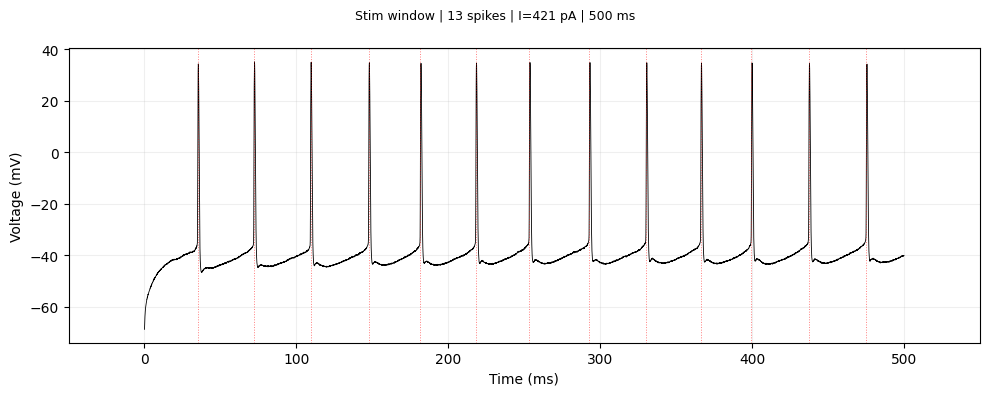

In [18]:
# Crop to stimulation window (500 ms max)
data = crop_to_stim_window(trace, max_duration_ms=500.0)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Initial simulation: 8 spikes, firing rate 13.3 Hz
Experimental:       13 spikes
{'C_m': 200.0, 'g_L': 12.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 300.0, 'a': 2.0, 'b': 60.0, 'I': 500.0}


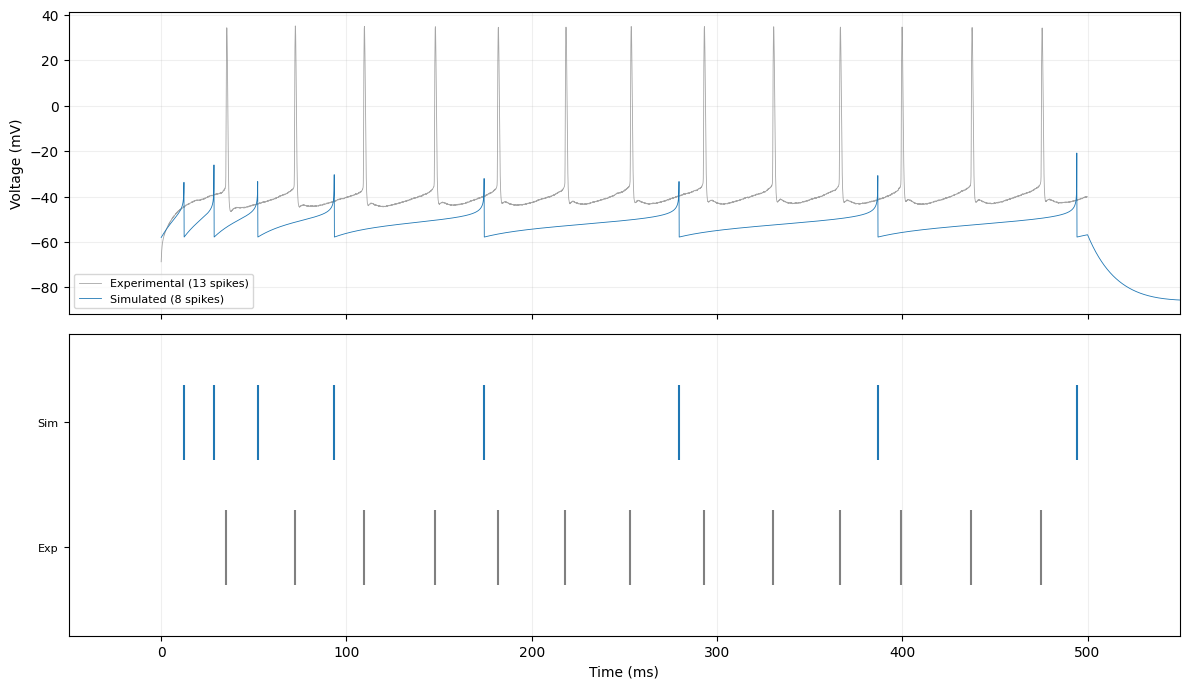

In [19]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0  # required by create_adex_cell

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz")
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init);

print(initial_params)

## 3. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [20]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
target_voltage = jnp.array(data.voltage)
stim_end_index = data.stim_end_idx

# --- Stage 1 config: Polyak optimizer, 250 epochs ---
config_stage1 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=500,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=100,
    polyak_alpha=1.0,
    polyak_beta=1.0,
    clip_to_bounds=True,
    verbose=True,
    return_best=True,
)

# config_stage1 = TrainingConfig(
#     optimizer="adam",
#     learning_rate=0.005,
#     n_epochs=600,
#     surrogate_type="sigmoid",
#     surrogate_slope=5.0,
#     print_every=100,
#     clip_to_bounds=True,
#     verbose=True,
#     return_best=True,
#     grad_clip_norm=10.0,
#     lr_schedule='exponential',
#     lr_decay_rate=0.5  # final/initial LR ratio for exponential decay
# )

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage1,
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=target_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
)

loss_fn_stage1 = make_guarino_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
    loss_config=GuarinoLossConfig(
        weight_t_first=25.0,
        weight_t_second=20.0,
        weight_t_third=15.0,
        weight_t_last=10.0,
        weight_firing_freq=20.0,
        weight_spike_count=0.2,
    ),
)

print(f"Initial Guarino loss: {float(loss_fn_stage1(trainable_params1)):.4f}")
print(trainable_params1)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Initial Guarino loss: 43.7432
[{'AdEx_g_L': Array([12.], dtype=float32)}, {'AdEx_E_L': Array([-70.], dtype=float32)}, {'AdEx_v_T': Array([-50.], dtype=float32)}, {'AdEx_v_reset': Array([-58.], dtype=float32)}, {'AdEx_tau_w': Array([300.],

In [21]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=500 surrogate=sigmoid slope=5.0 alpha=1.0 beta=1.0
Epoch    0 | loss=43.743214 | grad_norm=5.68e-01 | lr=2.19e-01 | g_L=11.8771, E_L=-69.9020, v_T=-50.0869, v_reset=-58.0015, tau_w=299.9962, a=1.8766, b=59.9818
Epoch  100 | loss=39.955170 | grad_norm=5.36e-02 | lr=2.00e-01 | g_L=5.7185, E_L=-65.8984, v_T=-49.0129, v_reset=-55.8070, tau_w=299.6229, a=0.0000, b=57.6017
Epoch  200 | loss=37.159081 | grad_norm=1.53e-01 | lr=1.86e-01 | g_L=3.7935, E_L=-65.3612, v_T=-46.0075, v_reset=-55.2245, tau_w=299.4194, a=0.0000, b=56.6657
Epoch  300 | loss=34.498997 | grad_norm=5.29e+01 | lr=1.72e-01 | g_L=3.1328, E_L=-65.3254, v_T=-43.4837, v_reset=-54.8402, tau_w=299.3139, a=0.1106, b=56.4325
Epoch  400 | loss=31.654476 | grad_norm=2.79e-02 | lr=1.58e-01 | g_L=3.0545, E_L=-65.3685, v_T=-40.9141, v_reset=-54.3680, tau_w=299.2235, a=0.0117, b=56.2497
Training complete: final_loss=34.790733 best_loss=31.515825 (epoch 405) total_time=311.4s mean_epoch=622.9ms l


Stage 1 complete.
  Best loss:   31.5158
  Total time:  311.4 s


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:87: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Stage 1: 13 spikes (target: 13)
Gamma = -0.116


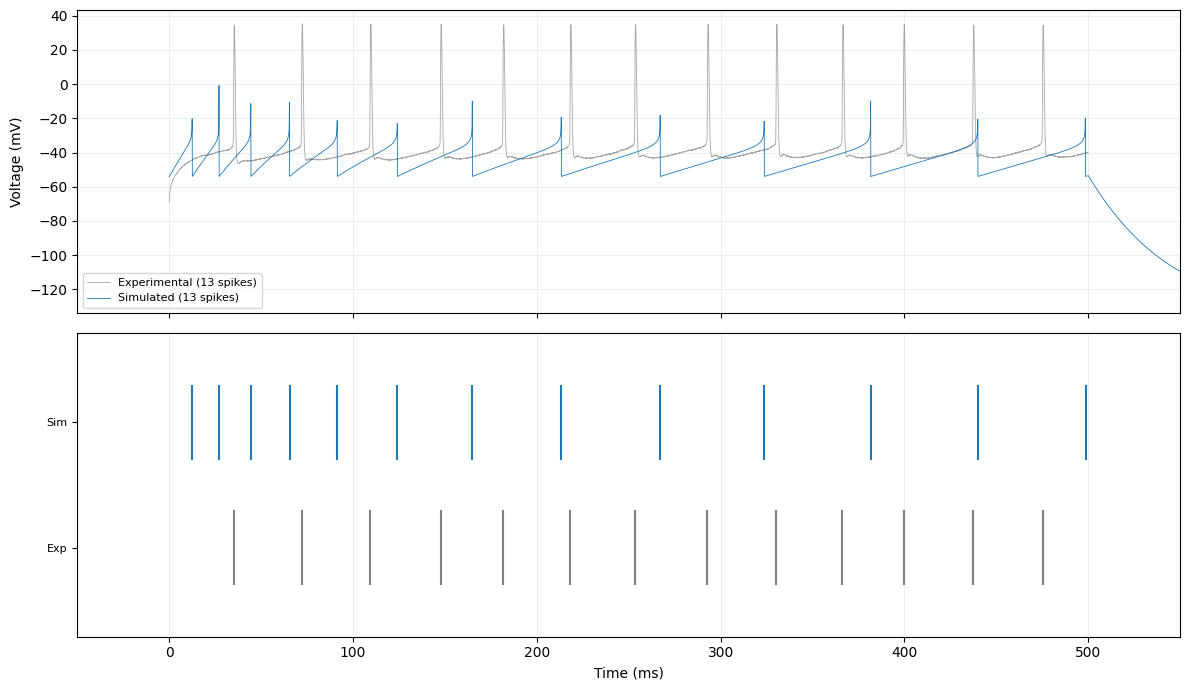

In [22]:
# Evaluate stage 1: simulate and check spike count + Gamma
trained_s1 = result_stage1.get_params_dict()
params_after_s1 = dict(initial_params)
params_after_s1.update(trained_s1)

sim_stage1 = simulate_jaxley(
    params=params_after_s1,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1);

## 4. Stage 2 — Soft-DTW Fine-Tuning

In [23]:
# Stage 2 starts from stage 1's trained parameters
stage2_params = dict(initial_params)
stage2_params.update(result_stage1.get_params_dict())

print("Stage 2 initial parameters (from stage 1):")
for k, v in result_stage1.get_params_dict().items():
    init_v = initial_params.get(k, float("nan"))
    print(f"  {k:<12} {init_v:>10.3f} -> {v:>10.3f}")

# --- Stage 2 config: Adam with lower LR for fine-tuning ---
# config_stage2 = TrainingConfig(
#     optimizer="adam",
#     learning_rate=0.001,
#     n_epochs=200,
#     surrogate_type="sigmoid",
#     surrogate_slope=5.0,
#     print_every=50,
#     clip_to_bounds=True,
#     verbose=True,
#     return_best=True,
#     grad_clip_norm=10.0,
# )

config_stage2 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=300,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=50,
    polyak_alpha=1.0,
    polyak_beta=1.0,
    clip_to_bounds=True,
    verbose=True,
    return_best=True,
)


# Re-create cell for stage 2 (loss fn closure captures the cell)
cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=stage2_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage2,
)

loss_fn_stage2 = make_soft_dtw_loss_fn(
    cell=cell2,
    data_stimuli=data_stimuli2,
    t_max=t_max2,
    dt_ms=data.dt_ms,
    exp_voltage=target_voltage,
    stim_end_index=stim_end_index,
    loss_config=SoftDTWLossConfig(),
)

print(f"\nInitial Soft-DTW loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

Stage 2 initial parameters (from stage 1):
  g_L              12.000 ->      3.338
  E_L             -70.000 ->    -65.429
  v_T             -50.000 ->    -40.624
  v_reset         -58.000 ->    -54.182
  tau_w           300.000 ->    299.227
  a                 2.000 ->      0.196
  b                60.000 ->     56.285
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Nu

In [24]:
result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=stage2_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=300 surrogate=sigmoid slope=5.0 alpha=1.0 beta=1.0
Epoch    0 | loss=45.716316 | grad_norm=4.79e+02 | lr=2.29e-01 | g_L=3.1643, E_L=-65.3938, v_T=-40.7005, v_reset=-54.1402, tau_w=299.2235, a=0.0904, b=56.2375
Epoch   50 | loss=43.622997 | grad_norm=3.99e+02 | lr=2.18e-01 | g_L=1.3422, E_L=-65.0957, v_T=-41.3279, v_reset=-53.7485, tau_w=299.1462, a=0.3701, b=55.4638
Epoch  100 | loss=42.379757 | grad_norm=1.92e+04 | lr=2.12e-01 | g_L=1.0769, E_L=-65.0157, v_T=-41.2240, v_reset=-53.8032, tau_w=299.1024, a=0.1091, b=54.9557
Epoch  150 | loss=40.905975 | grad_norm=4.10e+02 | lr=2.05e-01 | g_L=1.0000, E_L=-64.9745, v_T=-41.2747, v_reset=-53.2814, tau_w=299.0962, a=0.0000, b=54.6884
Epoch  200 | loss=42.217236 | grad_norm=1.54e+05 | lr=2.11e-01 | g_L=1.0000, E_L=-64.9363, v_T=-40.8023, v_reset=-53.7843, tau_w=299.0640, a=0.0000, b=54.3919
Epoch  250 | loss=42.484840 | grad_norm=5.22e+02 | lr=2.12e-01 | g_L=1.2791, E_L=-64.8878, v_T=-40.4927, v_rese


Stage 2 complete.
  Best loss:   38.6598
  Total time:  249.2 s


## 5. Results

In [25]:
# Final simulation with stage 2 parameters
trained_s2 = result_stage2.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_s2)

sim_final = simulate_jaxley(
    params=params_final,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Final simulation: {sim_final.n_spikes} spikes (target: {data.n_spikes})")

if sim_final.n_spikes > 0 and data.n_spikes > 0:
    cf_final = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_final.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Coincidence factor Gamma = {cf_final.gamma:.3f} (target > 0.5)")
else:
    cf_final = None
    print("Coincidence factor: N/A (no spikes)")

# Compare with stage 1
if cf_s1 is not None:
    gamma_s2 = f"{cf_final.gamma:.3f}" if cf_final else "N/A"
    print(f"\nStage 1 Gamma: {cf_s1.gamma:.3f} -> Stage 2 Gamma: {gamma_s2}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:87: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Final simulation: 15 spikes (target: 13)
Coincidence factor Gamma = 0.036 (target > 0.5)

Stage 1 Gamma: -0.116 -> Stage 2 Gamma: 0.036


In [26]:
# Show trained parameter values
print("Parameter progression: initial -> stage 1 -> stage 2")
print(f"{'Parameter':<12} {'Initial':>10} {'Stage 1':>10} {'Stage 2':>10} {'Bounds':>20}")
print("-" * 65)
for k in trained_s2:
    init_v = initial_params.get(k, float("nan"))
    s1_v = trained_s1.get(k, float("nan"))
    s2_v = trained_s2[k]
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {s1_v:>10.3f} {s2_v:>10.3f} {bounds_str:>20}")

Parameter progression: initial -> stage 1 -> stage 2
Parameter       Initial    Stage 1    Stage 2               Bounds
-----------------------------------------------------------------
g_L              12.000      3.338      1.000          [1.0, 50.0]
E_L             -70.000    -65.429    -64.834       [-90.0, -50.0]
v_T             -50.000    -40.624    -41.276       [-60.0, -30.0]
v_reset         -58.000    -54.182    -53.350       [-80.0, -40.0]
tau_w           300.000    299.227    299.022        [10.0, 500.0]
a                 2.000      0.196      0.000          [0.0, 10.0]
b                60.000     56.285     53.871         [0.0, 200.0]


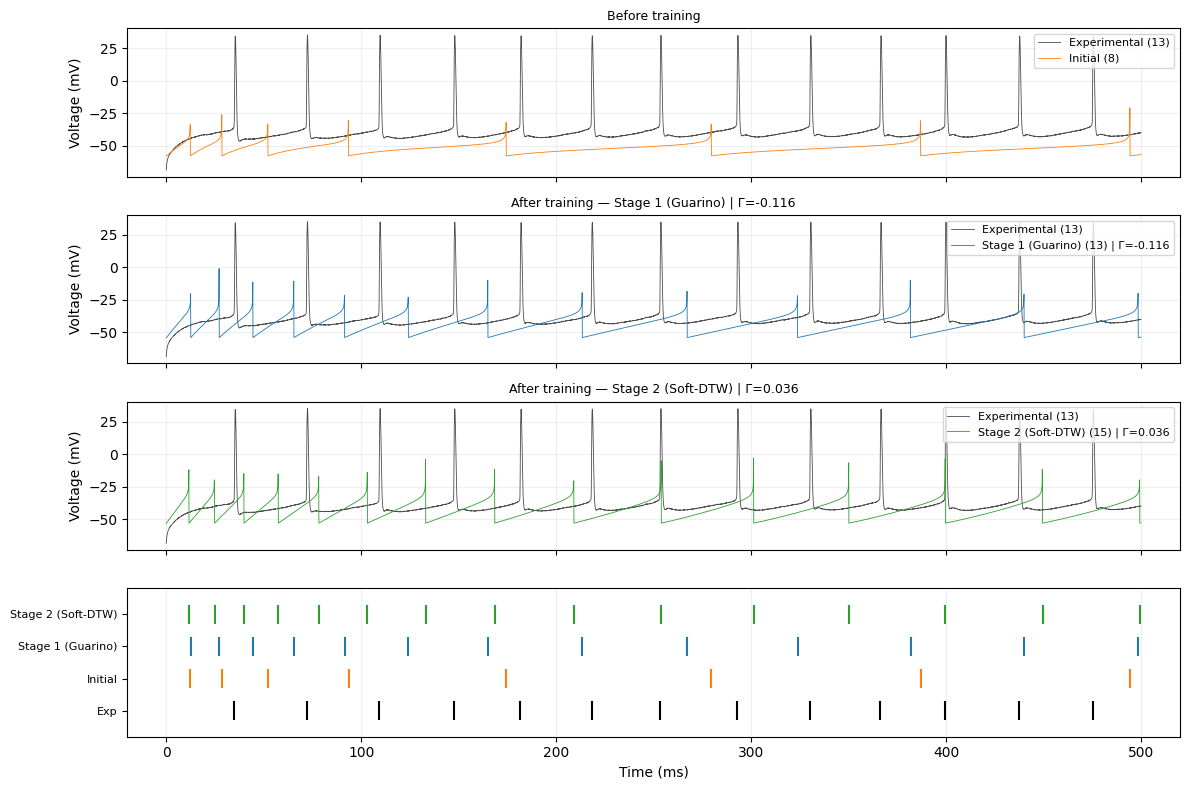

In [27]:
fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1, sim_final],
    coincidence=[cf_s1, cf_final],
    labels=["Stage 1 (Guarino)", "Stage 2 (Soft-DTW)"],
);

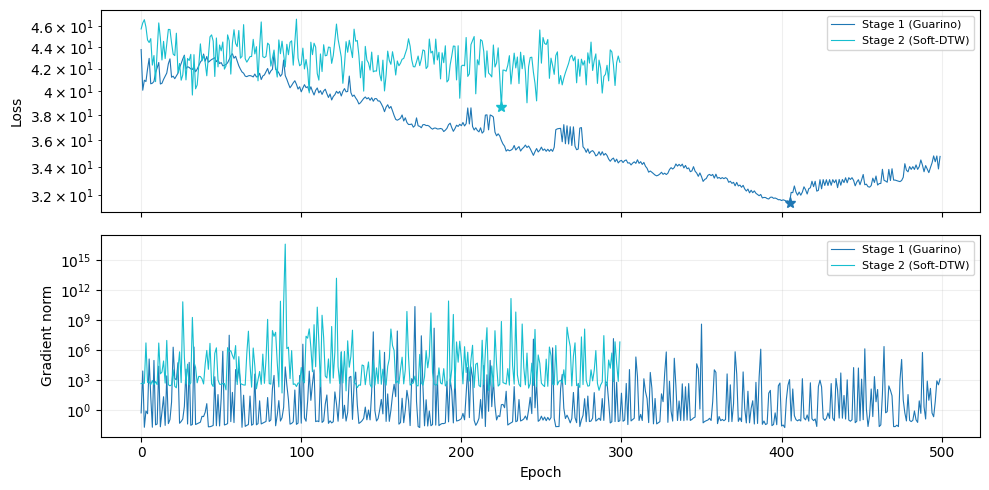

In [28]:
training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1 (Guarino)", "Stage 2 (Soft-DTW)"],
    show_grad_norms=True,
);

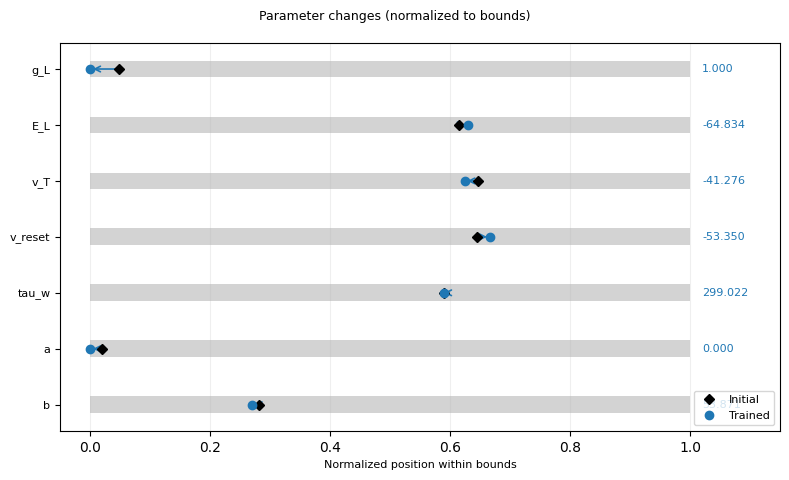

In [29]:
parameter_comparison_plot(result_stage2);

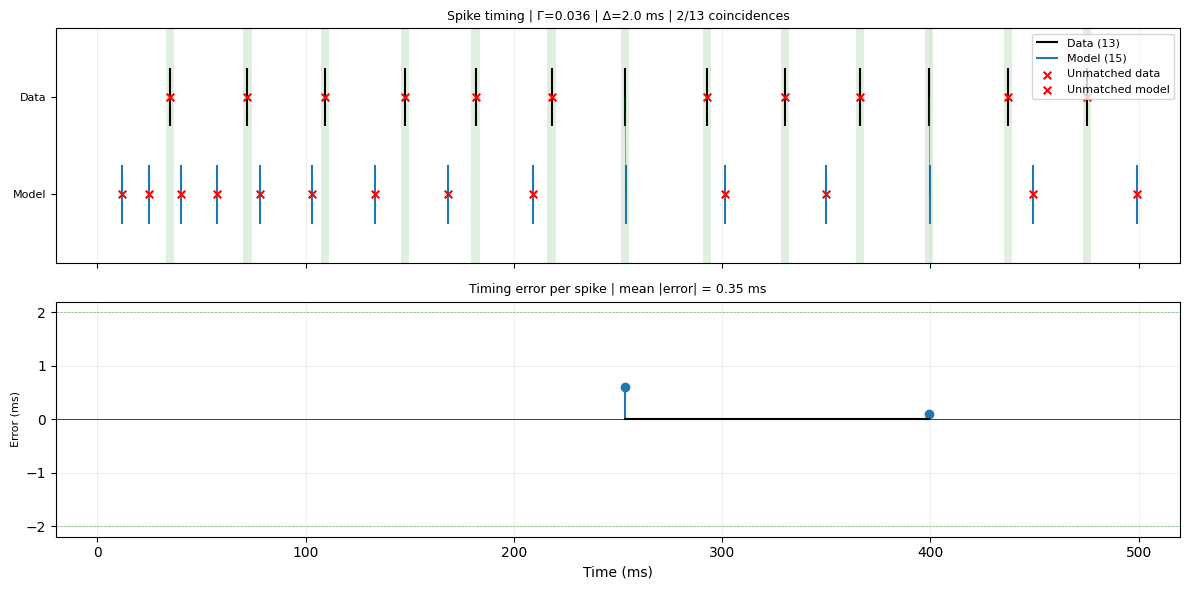

In [30]:
if cf_final is not None:
    spike_timing_plot(data, sim_final, cf_final)
else:
    print("Spike timing plot skipped (no spikes)")